# **PHÂN TÍCH VÀ DỰ BÁO DOANH SỐ CHUỖI CỬA HÀNG WALMART**


## **I. Định nghĩa vấn đề (Define Problem)**

**Mô tả**:

Bộ dữ liệu được sử dụng trong nghiên cứu này là bộ dữ liệu Dự đoán Doanh số Bán hàng của Walmart ("Walmart Recruiting - Store Sales Forecasting"), có nguồn gốc từ một cuộc thi Kaggle do Walmart tổ chức.

Bộ dữ liệu Walmart Store Sales Forecasting (Kaggle) được xây dựng để dự đoán doanh số bán hàng hàng tuần (Weekly_Sales) theo cấp Store × Dept, dựa trên lịch sử bán hàng và bối cảnh kinh tế – khu vực.

Tập huấn luyện gồm 421.570 dòng cho 45 cửa hàng trên toàn quốc, có độ phân giải theo tuần từ 05/02/2010 đến 01/11/2012, bao gồm các trường Store, Dept, Date, Weekly_Sales và cờ IsHoliday để đánh dấu các tuần lễ đặc biệt. 

Dữ liệu được ghép đa bảng: bảng bán hàng lõi, bảng mô tả cửa hàng với Type (A/B/C) và Size, cùng bảng chỉ số theo tuần phản ánh môi trường hoạt động như Temperature, Fuel_Price, CPI, Unemployment và các trường MarkDown1–5 đại diện khuyến mại ẩn danh chỉ xuất hiện từ 11/2011 và không đầy đủ cho mọi cửa hàng. 

Nhờ cấu trúc này, có thể đồng thời mô hình hóa tác động của mùa vụ, ngày lễ, loại và quy mô cửa hàng, biến động kinh tế và chương trình khuyến mại lên doanh số, từ đó phục vụ các quyết định tối ưu như lập kế hoạch tồn kho, phân bổ nhân sự, định thời điểm khuyến mại và dự báo nhu cầu ở mức chi tiết từng cửa hàng và phòng ban.

**Data Source :** https://www.kaggle.com/c/walmart-recruiting-store-sales-forecasting/data <br>

## **II. Chuẩn bị vấn đề (Prepare Problem)**

### **1. Khai báo thư viện (Load Libraries)**

In [2]:
# Importing all import python libraries
import pandas as pd
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick 

### **2. Nạp dữ liệu (Load Dataset)**

#### **2.1. Data Overview** 

Dữ liệu chứa tất cả 4 datasets bao gồm stores.csv, train.csv, test.csv và features.csv

##### **1) stores.csv**

Tập dữ liệu stores.csv cung cấp bối cảnh cần thiết về đặc điểm vật lý của các cửa hàng, giúp mô hình dự đoán xác định liệu các biến cố định như loại và quy mô địa điểm có phải là yếu tố thúc đẩy doanh số bán hàng mạnh mẽ hay không, đặc biệt khi so sánh với các yếu tố thay đổi theo thời gian như nhiệt độ hoặc giá nhiên liệu.

In [3]:
stores_df = pd.read_csv("dataset/stores.csv")
#shape()
print(f"Kích thước: {stores_df.shape}")
#info()
print("Thuộc tính")
stores_df.info()
#head()
print("Dữ liệu mẫu")
stores_df.head()

Kích thước: (45, 3)
Thuộc tính
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB
Dữ liệu mẫu


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


**Nhận xét:**

Đối với dataset stores:

- Dữ liệu bao gồm 45 dòng và 3 cột.
- Thông tin dữ liệu:

<table style="width:100%; border-collapse:collapse; margin:auto; text-align:center;">
  <thead>
    <tr>
      <th style="border:1px solid #ddd; padding:8px;">Tên cột</th>
      <th style="border:1px solid #ddd; padding:8px;">Ý nghĩa</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Store</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã định danh cửa hàng (1–45)</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Type</td>
      <td style="border:1px solid #ddd; padding:8px;">Loại hình cửa hàng (A/B/C) phản ánh format và quy mô</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Size</td>
      <td style="border:1px solid #ddd; padding:8px;">Diện tích sàn bán hàng (square feet)</td>
    </tr>
  </tbody>
</table>

##### **2) train.csv**

Bộ dữ liệu train.csv là nền tảng lịch sử chứa tất cả các quan sát bán hàng thực tế, cho phép mô hình học hỏi từ quá khứ để đưa ra dự đoán cho tương lai.

In [4]:
train_df = pd.read_csv("dataset/train.csv")
#shape()
print(f"Kích thước: {train_df.shape}")
#info()
print("Thuộc tính")
train_df.info()
#head()
print("Dữ liệu mẫu")
train_df.head()

Kích thước: (421570, 5)
Thuộc tính
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
Dữ liệu mẫu


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


**Nhận xét:**

Đối với dataset test:
 
- Dữ liệu bao gồm 421570 dòng và 5 cột.
- Thông tin dữ liệu:

<table style="width:100%; border-collapse:collapse; margin:auto; text-align:center;">
  <thead>
    <tr>
      <th style="border:1px solid #ddd; padding:8px;">Tên cột</th>
      <th style="border:1px solid #ddd; padding:8px;">Ý nghĩa</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Store</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã định danh cửa hàng (1–45).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Dept</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã phòng ban/ngành hàng trong từng cửa hàng.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Date</td>
      <td style="border:1px solid #ddd; padding:8px;">Ngày đại diện cho tuần bán hàng (dữ liệu theo tuần).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Weekly_Sales</td>
      <td style="border:1px solid #ddd; padding:8px;">Doanh số bán hàng trong tuần của cặp <i>Store × Dept</i> (đơn vị tiền tệ gốc của Walmart).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">IsHoliday</td>
      <td style="border:1px solid #ddd; padding:8px;">Cờ True/False: tuần trùng kỳ nghỉ đặc biệt (Super Bowl, Labor Day, Thanksgiving, Christmas).</td>
    </tr>
  </tbody>
</table>



##### **3) test.csv**

Bộ dữ liệu test.csv là khu vực mục tiêu mà mô hình được huấn luyện cần phải thực hiện dự đoán, và nó đại diện cho các trường hợp bán hàng trong tương lai (hoặc chưa biết).

In [5]:
test_df = pd.read_csv("dataset/test.csv")
#shape()
print(f"Kích thước: {test_df.shape}")
#info()
print("Thuộc tính")
test_df.info()
#head()
print("Dữ liệu mẫu")
test_df.head()

Kích thước: (115064, 4)
Thuộc tính
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB
Dữ liệu mẫu


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


**Nhận xét:**

Đối với dataset test:

- Dữ liệu bao gồm 115064 dòng và 4 cột.
- Thông tin dữ liệu:

<table style="width:100%; border-collapse:collapse; margin:auto; text-align:center;">
  <thead>
    <tr>
      <th style="border:1px solid #ddd; padding:8px;">Tên cột</th>
      <th style="border:1px solid #ddd; padding:8px;">Ý nghĩa</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Store</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã định danh cửa hàng (1–45).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Dept</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã phòng ban (ngành hàng) trong từng cửa hàng.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Date</td>
      <td style="border:1px solid #ddd; padding:8px;">Ngày đại diện cho tuần bán hàng (dữ liệu theo tuần).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">IsHoliday</td>
      <td style="border:1px solid #ddd; padding:8px;">Cờ True/False: tuần có kỳ nghỉ đặc biệt (Super Bowl, Labor Day, Thanksgiving, Christmas).</td>
    </tr>
  </tbody>
</table>


##### **4) features.csv**

Bộ dữ liệu features.csv chứa dữ liệu bổ sung liên quan đến cửa hàng, phòng ban và các yếu tố hoạt động/khu vực tương ứng với các ngày bán hàng được ghi nhận

In [6]:
features_df = pd.read_csv("dataset/features.csv")
#shape()
print(f"Kích thước: {features_df.shape}")
#info()
print("Thuộc tính")
features_df.info()
#head()
print("Dữ liệu mẫu")
features_df.head()

Kích thước: (8190, 12)
Thuộc tính
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB
Dữ liệu mẫu
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        ---

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


**Nhận xét:**

Đối với dataset test:
 
- Dữ liệu bao gồm 8190 dòng và 12 cột.
- Thông tin dữ liệu:

<table style="width:100%; border-collapse:collapse; margin:auto; text-align:center;">
  <thead>
    <tr>
      <th style="border:1px solid #ddd; padding:8px;">Tên cột</th>
      <th style="border:1px solid #ddd; padding:8px;">Ý nghĩa</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Store</td>
      <td style="border:1px solid #ddd; padding:8px;">Mã định danh cửa hàng (1–45).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Date</td>
      <td style="border:1px solid #ddd; padding:8px;">Ngày đại diện cho tuần bán hàng (dữ liệu theo tuần).</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Temperature</td>
      <td style="border:1px solid #ddd; padding:8px;">Nhiệt độ trung bình khu vực của tuần.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Fuel_Price</td>
      <td style="border:1px solid #ddd; padding:8px;">Giá nhiên liệu trung bình khu vực của tuần.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">MarkDown1–5</td>
      <td style="border:1px solid #ddd; padding:8px;">Các chỉ số khuyến mại/giảm giá ẩn danh theo tuần.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">CPI</td>
      <td style="border:1px solid #ddd; padding:8px;">Chỉ số giá tiêu dùng (Consumer Price Index) của khu vực theo tuần.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">Unemployment</td>
      <td style="border:1px solid #ddd; padding:8px;">Tỷ lệ thất nghiệp khu vực theo tuần.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;">IsHoliday</td>
      <td style="border:1px solid #ddd; padding:8px;">Cờ True/False: tuần trùng kỳ nghỉ đặc biệt (Super Bowl, Labor Day, Thanksgiving, Christmas).</td>
    </tr>
  </tbody>
</table>




#### **2.2. Merge Datasets** 

Để có một bộ dữ liệu hoàn chỉnh phục vụ cho EDA và tiền xử lý, chúng ta cần merge 4 dataset theo các khóa chính phù hợp:

**Chiến lược merge:**
1. **Bước 1**: Merge `train` với `stores` theo khóa `Store` → Thêm thông tin loại cửa hàng và kích thước
2. **Bước 2**: Merge kết quả với `features` theo khóa `(Store, Date)` → Thêm các đặc trưng kinh tế và khuyến mại
3. **Kết quả**: Dataset tổng hợp chứa đầy đủ thông tin về doanh số, đặc điểm cửa hàng và bối cảnh kinh tế

**Lưu ý**: Dataset `test.csv` sẽ được merge tương tự khi cần dự đoán, nhưng hiện tại ta tập trung vào `train` để phân tích và xây dựng mô hình.

##### **Bước 1: Merge Train với Stores**
Ghép thông tin cửa hàng (Type, Size) vào dữ liệu bán hàng

In [7]:
# Merge train với stores theo cột Store
train_stores = pd.merge(train_df, stores_df, on='Store', how='left')

print(f"Kích thước sau khi merge train + stores: {train_stores.shape}")
print(f"Đã thêm các cột: {list(stores_df.columns[stores_df.columns != 'Store'])}")
print("\nXem dữ liệu mẫu sau merge:")
train_stores.head()

Kích thước sau khi merge train + stores: (421570, 7)
Đã thêm các cột: ['Type', 'Size']

Xem dữ liệu mẫu sau merge:


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
0,1,1,2010-02-05,24924.50,False,A,151315
1,1,1,2010-02-12,46039.49,True,A,151315
2,1,1,2010-02-19,41595.55,False,A,151315
3,1,1,2010-02-26,19403.54,False,A,151315
4,1,1,2010-03-05,21827.90,False,A,151315


##### **Bước 2: Merge với Features**
Ghép thêm các đặc trưng kinh tế và khuyến mại theo Store và Date

In [8]:
# Merge với features theo Store và Date
# Lưu ý: features có cột IsHoliday trùng với train, ta sẽ sử dụng từ train
walmart_data = pd.merge(train_stores, features_df, on=['Store', 'Date', 'IsHoliday'], how='left')

print(f"Kích thước dataset cuối cùng: {walmart_data.shape}")
#print(f"Tổng số cột: {walmart_data.shape[1]}")
#print(f"\nDanh sách các cột trong dataset tổng hợp:")
#print(walmart_data.columns.tolist())
print("\nXem dữ liệu mẫu của dataset đã merge:")
walmart_data.head()

Kích thước dataset cuối cùng: (421570, 16)

Xem dữ liệu mẫu của dataset đã merge:


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


##### **Bước 3: Kiểm tra Dataset sau Merge**

In [9]:
# Kiểm tra thông tin cơ bản của dataset
walmart_data.info()

# Lưu dataset đã merge vào file CSV để sử dụng lại
# walmart_data.to_csv('dataset/walmart_merged_data.csv', index=False)
# print("Đã lưu dataset vào 'dataset/walmart_merged_data.csv'")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


#### **2.3. Feature Engineering - Xử lý cột Date** 

Để thuận tiện cho việc phân tích và trực quan hóa theo thời gian, ta sẽ tách cột `Date` thành các thành phần riêng biệt.

In [10]:
# Chuyển đổi cột Date sang định dạng datetime
walmart_data['Date'] = pd.to_datetime(walmart_data['Date'], format='%Y-%m-%d')

# Tách thành các cột riêng biệt
walmart_data['Year'] = walmart_data['Date'].dt.year
walmart_data['Month'] = walmart_data['Date'].dt.month
walmart_data['Week'] = walmart_data['Date'].dt.isocalendar().week
walmart_data['Quarter'] = walmart_data['Date'].dt.quarter

print(f"Kích thước dataset hiện tại: {walmart_data.shape}")
print("\nXem một số dòng dữ liệu:")
walmart_data[['Date', 'Year', 'Month', 'Week', 'Quarter']].head(10)

Kích thước dataset hiện tại: (421570, 20)

Xem một số dòng dữ liệu:


,Date,Year,Month,Week,Quarter
0,2010-02-05,2010,2,5,1
1,2010-02-12,2010,2,6,1
2,2010-02-19,2010,2,7,1
3,2010-02-26,2010,2,8,1
4,2010-03-05,2010,3,9,1
5,2010-03-12,2010,3,10,1
6,2010-03-19,2010,3,11,1
7,2010-03-26,2010,3,12,1
8,2010-04-02,2010,4,13,2
9,2010-04-09,2010,4,14,2


**Nhận xét:**

Sau khi đã merge và chuẩn hóa cột `Date` thành các phần khác nhau. Dữ liệu cuối bao gồm 421570 và 20 cột.

## 3. Phân tích dữ liệu (Analyze Data)

### 3.1. Thống kê mô tả (Descriptive Statistics)

#### 1) **Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [11]:
# shape
print(f'+ Shape: {walmart_data.shape}')
# head, tail
print(f'+ Contents: ')
display.display(walmart_data.head(5))
display.display(walmart_data.tail(5))
# info
walmart_data.info()

+ Shape: (421570, 20)
+ Contents: 


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Quarter
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,5,1
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,6,1
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,7,1
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,8,1
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,9,1


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Quarter
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9,39,3
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10,40,4
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10,41,4
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10,42,4
421569,45,98,2012-10-26,1076.80,False,B,118221,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,2012,10,43,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

**Nhận xét**:

Dữ liệu có 20 tính chất để phân lớp: Store, Dept, Date, IsHoliday, Type, Size, Temperature, Fuel_Price, MarkDown1, MarkDown2, MarkDown3, MarkDown4, MarkDown5, CPI, Unemployment, Year, Month, Day, Week, DayOfWeek, Quarter    

Tổng số dòng dữ liệu là 421570 dòng

Dữ liệu để target ở cột **Weekly_Sales** 

`Tuy nhiên các Dtype (kiểu dữ liệu) ở mỗi cột chưa chính xác, cần kiểm tra.`

Các cột cần kiểm tra bao gồm:
- Store
- Dept
- IsHoliday
- Type
- Year
- Month
- Day
- Week
- DayOfWeek
- Quarter

In [12]:
# check unique của các cột trong data train
print("Store:")
display.display(walmart_data["Store"].unique())
print("Dept:")
display.display(walmart_data["Dept"].unique())
print("IsHoliday:")
display.display(walmart_data["IsHoliday"].unique())
print("Type:")
display.display(walmart_data["Type"].unique())
print("Year:")
display.display(walmart_data["Year"].unique())
print("Month:")
display.display(walmart_data["Month"].unique())
print("Week:")
display.display(walmart_data["Week"].unique())
print("Quarter:")
display.display(walmart_data["Quarter"].unique())

Store:


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45], dtype=int64)

Dept:


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 40, 41, 42, 44, 45, 46, 47, 48, 49, 51, 52, 54, 55, 56,
       58, 59, 60, 67, 71, 72, 74, 77, 78, 79, 80, 81, 82, 83, 85, 87, 90,
       91, 92, 93, 94, 95, 96, 97, 98, 99, 39, 50, 43, 65], dtype=int64)

IsHoliday:


...

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1])

Week:


<IntegerArray>
[ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42,
 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,  1,  2,  3,  4]
Length: 52, dtype: UInt32

Quarter:


array([1, 2, 3, 4])

**Nhận xét:**

Dựa vào các giá trị có trong các cột trên thì các cột $Store$, $Dept$, $IsHoliday$, $Type$, $Year$, $Month$, $Week$ và $Quarter$ là các cột có giá trị phân loại (categorical) không phải giá trị số (numerical) hoặc giá trị object cần chuyển đổi kiểu dữ liệu của các cột này.

#### 2) **Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [13]:
n_rows = len(walmart_data)
n_duplicated = walmart_data.duplicated().sum()

missing_cols = (
    walmart_data.isna().sum()
      .loc[lambda s: s > 0]  # lọc cột có thiếu
      .sort_values(ascending=False)
)

summary = (
    pd.DataFrame({
        "column": missing_cols.index,
        "missing_count": missing_cols.values,
        "missing_pct": (missing_cols.values / n_rows * 100).round(2)
    })
)

# Nếu muốn hiển thị % kèm dấu %
summary["missing_pct"] = summary["missing_pct"].astype(str) + "%"

print("Các cột có giá trị thiếu:")
display.display(summary)

print(f'Số dòng trùng: {n_duplicated}')

if n_duplicated > 0:
    n_duplicated_rows = walmart_data[walmart_data.duplicated(keep=False)]
    display.display(n_duplicated_rows)

Các cột có giá trị thiếu:


,column,missing_count,missing_pct
0,MarkDown2,310322,73.61%
1,MarkDown4,286603,67.98%
2,MarkDown3,284479,67.48%
3,MarkDown1,270889,64.26%
4,MarkDown5,270138,64.08%


Số dòng trùng: 0


**Nhận xét**:

Dữ liệu có giá trị rỗng (NaN, Null) và không có dòng bị trùng.

Các cột có giá trị rỗng là `MarkDown1, MarkDown2, MarkDown3, MarkDown4 và MarkDown5.`

#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [14]:
walmart_data.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,421570.0,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
Dept,421570.0,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
Date,421570,2011-06-18 08:30:31.963375104,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421570.0,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519
Size,421570.0,136727.915739,34875.0,93638.0,140167.0,202505.0,219622.0,60980.583328
Temperature,421570.0,60.090059,-2.06,46.68,62.09,74.28,100.14,18.447931
Fuel_Price,421570.0,3.361027,2.472,2.933,3.452,3.738,4.468,0.458515
MarkDown1,150681.0,7246.420196,0.27,2240.27,5347.45,9210.9,88646.76,8291.221345
MarkDown2,111248.0,3334.628621,-265.76,41.6,192.0,1926.94,104519.54,9475.357325
MarkDown3,137091.0,1439.421384,-29.1,5.08,24.6,103.99,141630.61,9623.07829


**Nhận xét**:

Đối với $Date$:
- Dữ liệu được phân chia ở các phần (25%, 50%, 75%) nằm lần lượt quanh 2010-10, 2011-06, 2012-02, cho thấy đủ cả 3 mùa liên tiếp.

Đối với $Markdown$:
- Xuất hiện các giá trị âm bất thường ở Markdown2 (min -265,76) và Mardown3 (min -29.1).

Đối với $Weekly_Sales$:
- Mean ~ 15,981, Median 7,612 lệch phải mạnh (nhiều tuần doanh số thấp, một số tuần rất cao).
- Max = 693,099, std ~ 22,711 > mean chot thấy độ biến thiên lớn, có outlier.

Đối với $Size$:
- mean ~ 136,728 > std lớn (~60,980) phản ánh chênh lệch quy mô giữa Type A/B/C


## **4. EDA and DATA VISUALIZATION**

### **4.1. Phân tích mô tả**

#### **1) Doanh số bán hàng trung bình theo loại cửa hàng (A, B, C) là bao nhiêu và Tỷ lệ phân phối các loại cửa hàng trong bộ dữ liệu là gì?**

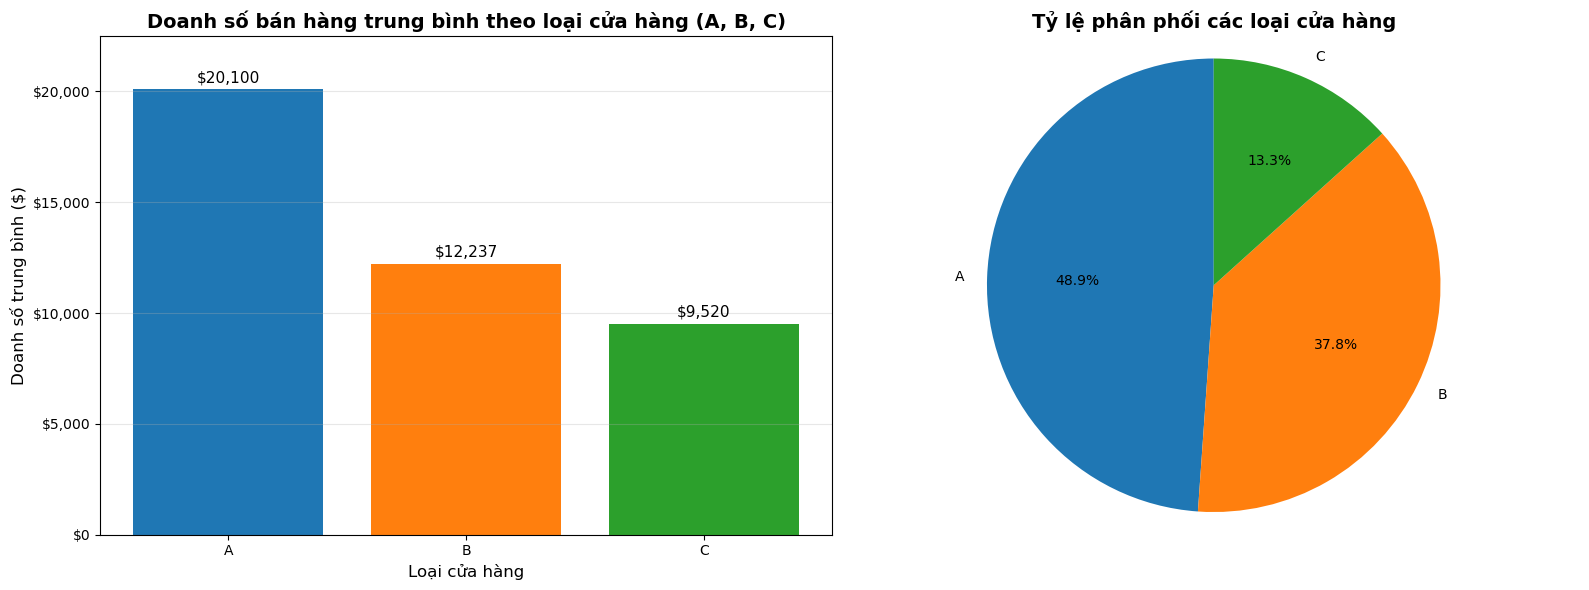

In [15]:
import matplotlib.ticker as mtick
# Tính dữ liệu
avg_sales_by_type = (
    walmart_data.groupby('Type')['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
)
store_type_counts = walmart_data.groupby('Type')['Store'].nunique().reindex(['A','B','C'])

# Vẽ 2 chart cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart Doanh số trung bình theo Type
bars = axes[0].bar(avg_sales_by_type.index, avg_sales_by_type.values,
                color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Doanh số bán hàng trung bình theo loại cửa hàng (A, B, C)',
                fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loại cửa hàng', fontsize=12)
axes[0].set_ylabel('Doanh số trung bình ($)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, avg_sales_by_type.max() * 1.12)
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axes[0].tick_params(axis='x', labelrotation=0)

# gắn nhãn giá trị lên từng cột
for bar, v in zip(bars, avg_sales_by_type.values):
    axes[0].annotate(f"${v:,.0f}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)

# Pie chart Tỷ lệ loại cửa hàng 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
axes[1].pie(
    store_type_counts.values,
    labels=store_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
axes[1].set_title('Tỷ lệ phân phối các loại cửa hàng',
                fontsize=14, fontweight='bold')
axes[1].axis('equal')  # giữ hình tròn chuẩn

plt.tight_layout()
plt.show()


**Nhận xét:**

Dựa vào thông tin 2 chart thì do cửa hàng A chiếm tỷ lệ lớn nhất **(48.89%)** vì thế doanh số trung bình cũng cao nhất **($20,099.57)**.

Tiếp đến là cửa hàng B chiếm **(37.78%)** và doạnh số trùng bình **($12,237.08)**.

Cuối cùng là cửa hàng C có tỷ lệ nhỏ nhất chiếm **(13.33%)** và doanh số trung bình **($9,519.53)**.




In [16]:
# So sánh Size trung bình của các loại cửa hàng
print("\nSO SÁNH KÍCH THƯỚC CỬA HÀNG (SIZE)")
print("-" * 60)
size_by_type = walmart_data.groupby('Type').agg({
    'Size': ['mean', 'min', 'max', 'std'],
    'Store': 'nunique'
}).round(2)
size_by_type.columns = ['Size_Mean', 'Size_Min', 'Size_Max', 'Size_Std', 'Số_cửa_hàng']
print(size_by_type)

# 2. So sánh số lượng phòng ban trung bình
print("\n2. SO SÁNH SỐ LƯỢNG PHÒNG BAN")
print("-" * 60)
dept_by_type = walmart_data.groupby('Type')['Dept'].nunique().sort_values(ascending=False)
print(dept_by_type)



SO SÁNH KÍCH THƯỚC CỬA HÀNG (SIZE)
------------------------------------------------------------
      Size_Mean  Size_Min  Size_Max  Size_Std  Số_cửa_hàng
Type                                                      
A     182231.29     39690    219622  41534.53           22
B     101818.74     34875    140167  30921.78           17
C      40535.73     39690     42988   1194.43            6

2. SO SÁNH SỐ LƯỢNG PHÒNG BAN
------------------------------------------------------------
Type
A    81
B    80
C    66
Name: Dept, dtype: int64


**Nhận xét:**

Dựa vào so sánh về kích thước (Size) và phòng ban (dept) cho thấy rằng số lượng phòng ban không phản ánh nhiều về sự chênh lệch doanh số, tuy nhiên đối với kích thước thì với Size_Mean(A) ~ 182231.29 cao hơn đáng kể so với Size_Mean(B) ~ 101818.74 và Size_Mean(C) ~ 40535.73. Điều đó phản ánh rằng diện tích lớn sẽ có nhiều sản phẩm hơn từ đó doanh số cửa hàng cao hơn

#### **2) Phòng ban nào (Department) có doanh số bán hàng trung bình cao nhất?**

In [28]:
walmart_data["Dept"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 40, 41, 42, 44, 45, 46, 47, 48, 49, 51, 52, 54, 55, 56,
       58, 59, 60, 67, 71, 72, 74, 77, 78, 79, 80, 81, 82, 83, 85, 87, 90,
       91, 92, 93, 94, 95, 96, 97, 98, 99, 39, 50, 43, 65], dtype=int64)

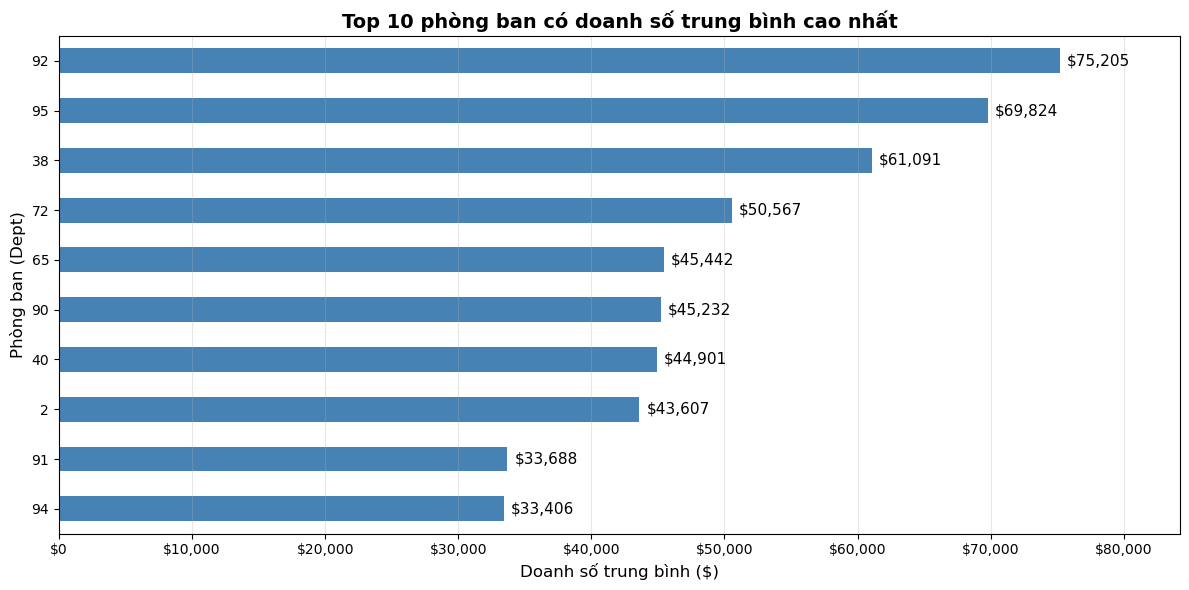

In [21]:
# Tính doanh số trung bình theo phòng ban
avg_sales_by_dept = walmart_data.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)
# Visualize Top 10
plt.figure(figsize=(12, 6))
avg_sales_by_dept.head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 phòng ban có doanh số trung bình cao nhất', fontsize=14, fontweight='bold')
plt.xlabel('Doanh số trung bình ($)', fontsize=12)
plt.ylabel('Phòng ban (Dept)', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

ax = plt.gca()
# Định dạng trục X dạng tiền tệ và chừa chỗ cho nhãn
vals = avg_sales_by_dept.head(10).values
ax.set_xlim(0, max(vals) * 1.12)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Gắn nhãn giá trị ở cuối mỗi cột (barh)
for bar, v in zip(ax.patches, vals):
    ax.annotate(f"${v:,.0f}",
                xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords="offset points",
                va='center', ha='left', fontsize=11)

plt.tight_layout()
plt.show()


**Nhận xét:**
- Phòng ban 92 có doanh số trung bình cao nhất: $75,204.87
- Top 3 phòng ban hàng đầu: [92, 95, 38]
- Có sự chênh lệch lớn giữa các phòng ban, cho thấy một số ngành hàng quan trọng hơn về mặt doanh thu

#### **4) Tổng doanh số bán hàng hàng tháng qua các năm (2010, 2011, 2012) có xu hướng như thế nào?**


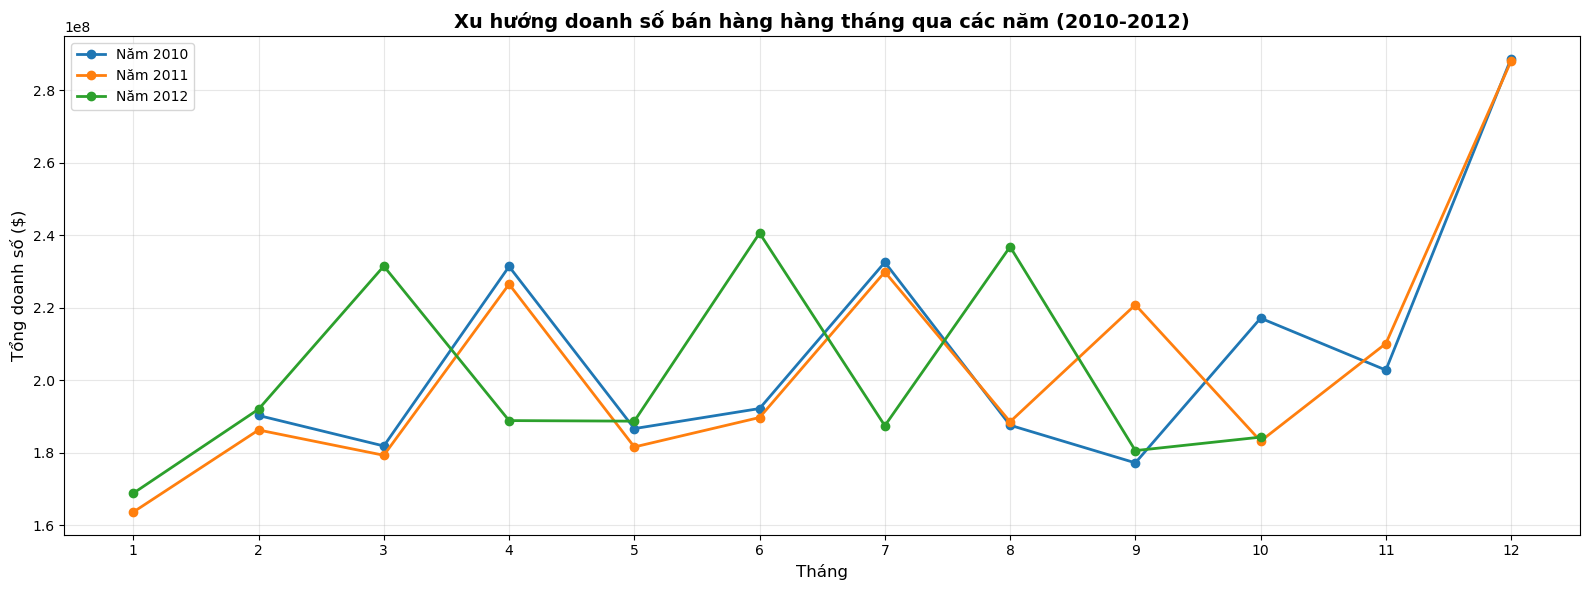

In [31]:
# Tính tổng doanh số theo tháng và năm
monthly_sales = walmart_data.groupby(['Year', 'Month'])['Weekly_Sales'].sum().reset_index()

# Tạo cột Year-Month để vẽ đồ thị dễ hơn
monthly_sales['Year_Month'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)

# Visualize
plt.figure(figsize=(16, 6))
for year in monthly_sales['Year'].unique():
    year_data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(year_data['Month'], year_data['Weekly_Sales'], marker='o', label=f'Năm {year}', linewidth=2)

plt.title('Xu hướng doanh số bán hàng hàng tháng qua các năm (2010-2012)', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng doanh số ($)', fontsize=12)
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Phân tích xu hướng:**

Tổng doanh số năm 2010: $2,288,886,120.41

Tổng doanh số năm 2011: $2,448,200,007.35

Tổng doanh số năm 2012: $2,000,132,859.35

**Nhận xét:**
- Doanh số có xu hướng tăng mạnh vào cuối năm (tháng 11-12) do mùa lễ hội
- Doanh số thấp nhất thường rơi vào đầu năm (tháng 1-2)
- Có sự tăng trưởng ổn định qua các năm

#### **5) Cửa hàng và phòng ban cụ thể nào tạo ra doanh số cao nhất?**


Top 10 cặp cửa hàng - phòng ban có doanh số cao nhất:

      Store  Dept  Weekly_Sales
1057     14    92   26101497.71
147       2    92   23572153.03
1523     20    92   23542625.04
980      13    92   23170876.20
297       4    92   22789210.43
1526     20    95   21537795.62
300       4    95   21054815.74
2061     27    92   20952094.22
1060     14    95   20655911.35
150       2    95   20533191.52


C:\Users\luong\AppData\Local\Temp\ipykernel_11620\1267595705.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10['Store_Dept'] = 'Store ' + top_10['Store'].astype(str) + ' - Dept ' + top_10['Dept'].astype(str)


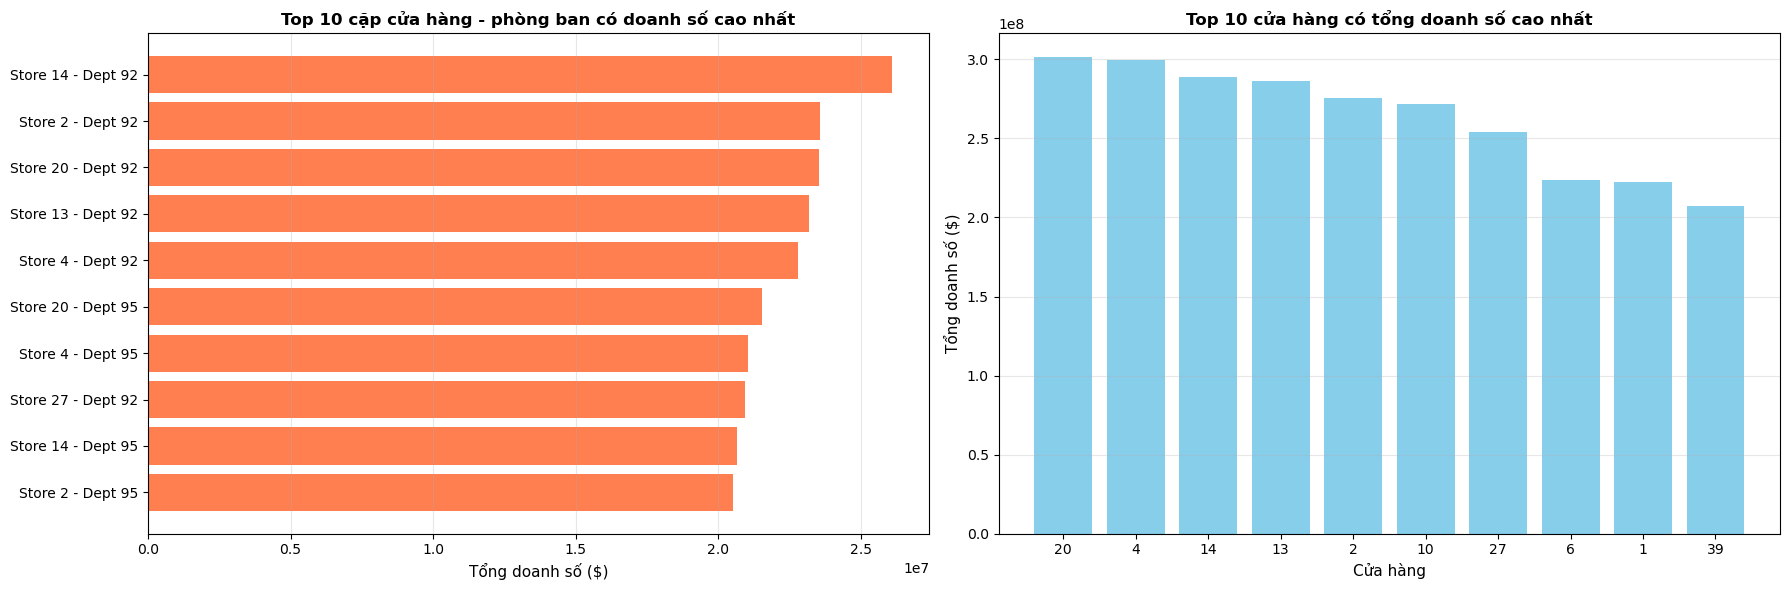


**Nhận xét:**
- Cửa hàng 14 - Phòng ban 92 có doanh số cao nhất: $26,101,497.71
- Cửa hàng 20 có tổng doanh số cao nhất trong toàn hệ thống: $301,397,792.46
- Sự tập trung doanh số vào một số cặp Store-Dept cho thấy cần tập trung nguồn lực vào các điểm bán hiệu quả


In [19]:
# Tính tổng doanh số theo Store và Dept
store_dept_sales = walmart_data.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().reset_index()
store_dept_sales = store_dept_sales.sort_values('Weekly_Sales', ascending=False)

print("Top 10 cặp cửa hàng - phòng ban có doanh số cao nhất:\n")
print(store_dept_sales.head(10))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 10 Store-Dept combinations
top_10 = store_dept_sales.head(10)
top_10['Store_Dept'] = 'Store ' + top_10['Store'].astype(str) + ' - Dept ' + top_10['Dept'].astype(str)
axes[0].barh(top_10['Store_Dept'], top_10['Weekly_Sales'], color='coral')
axes[0].set_title('Top 10 cặp cửa hàng - phòng ban có doanh số cao nhất', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tổng doanh số ($)', fontsize=11)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Top Stores
top_stores = walmart_data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)
axes[1].bar(top_stores.index.astype(str), top_stores.values, color='skyblue')
axes[1].set_title('Top 10 cửa hàng có tổng doanh số cao nhất', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cửa hàng', fontsize=11)
axes[1].set_ylabel('Tổng doanh số ($)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"\n**Nhận xét:**")
top_combo = store_dept_sales.iloc[0]
print(f"- Cửa hàng {int(top_combo['Store'])} - Phòng ban {int(top_combo['Dept'])} có doanh số cao nhất: ${top_combo['Weekly_Sales']:,.2f}")
print(f"- Cửa hàng {int(top_stores.index[0])} có tổng doanh số cao nhất trong toàn hệ thống: ${top_stores.iloc[0]:,.2f}")
print(f"- Sự tập trung doanh số vào một số cặp Store-Dept cho thấy cần tập trung nguồn lực vào các điểm bán hiệu quả")

### 4.2. Phân tích tương quan

#### **1) Có mối tương quan nào giữa doanh số bán hàng hàng tuần với kích thước cửa hàng (Store Size), loại cửa hàng (Type) và phòng ban (Department) hay không?**



#### **2) Sự thay đổi về nhiệt độ (Temperature) ảnh hưởng như thế nào đến doanh số bán hàng hàng tuần?**


#### **3) Mức độ thất nghiệp (Unemployment) có tác động gì đến doanh số bán hàng hàng tuần?**
 

#### **4) Giá nhiên liệu (Fuel Price) có mối tương quan như thế nào với doanh số bán hàng?**

### 4.3. Phân tích so sánh

#### **1) Doanh số bán hàng hàng tuần trong các tuần có ngày lễ (Holiday) có cao hơn đáng kể so với các tuần không có ngày lễ (Non-Holiday) hay không?**


#### **2) Doanh số bán hàng hàng tuần trong các tuần có ngày lễ (Holiday) có cao hơn đáng kể so với các tuần không có ngày lễ (Non-Holiday) hay không?**


#### **3) Doanh số bán hàng cuối năm (Week of Year Sales) có tăng lên đối với tất cả các loại cửa hàng (A, B, C) xung quanh dịp Lễ Tạ ơn và Giáng sinh không?**

# TIỀN XỬ LÝ

### 1. **Mối tương quan giữa các tính chất (Correlations)**

In [20]:

plt.figure(figsize=(15, 6)) #Create canvas
sns.heatmap(walmart_data.corr(), annot= True, cmap="coolwarm")
plt.show() 

ValueError: could not convert string to float: 'A'

<Figure size 1500x600 with 0 Axes>

**Nhận xét:** </br>
- Có nhiều cột tương quan dương rõ rệt như:
    - fixed_acidity - citric_acid (0.67)
    - fixed_acidity - density (0.67)
    - citric_acid - density (0.36)
    - citric_acid - sulphates (0.31)
    - residual_sugar - density (0.36)
    - chlorides - sulphates (0.37)
    - totalSO2 - freeSO2 (0.67)
    - alocohol - quality (0.48)
- Bên cạnh đó cũng có các cột tương quan âm:
    - fixed_acidity - pH (-0.68)
    - ctric_acid - volatile_acidity (-0.55)
    - ctric_acid - pH (-0.54)
    - density - alcohol (-0.5)
    - density - pH (-0.34)
    - volatile_acidity - quality (-0.39)

### 2. Các biểu đồ

1) Boxplot

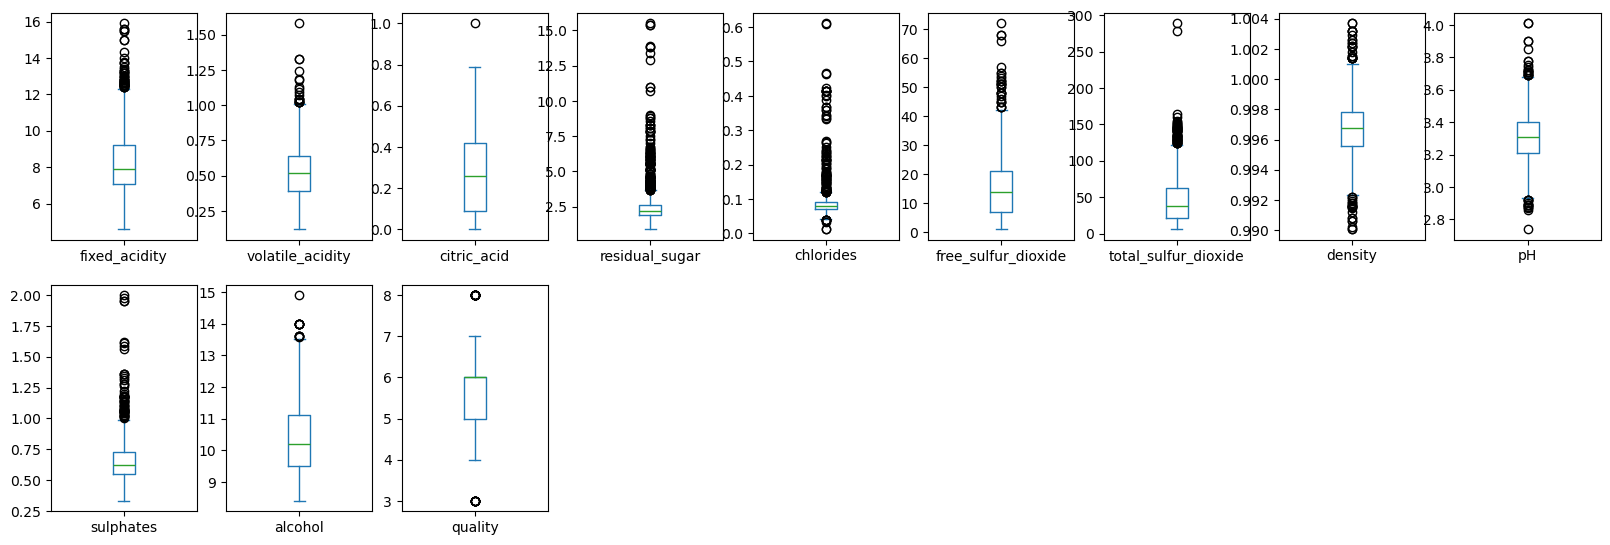

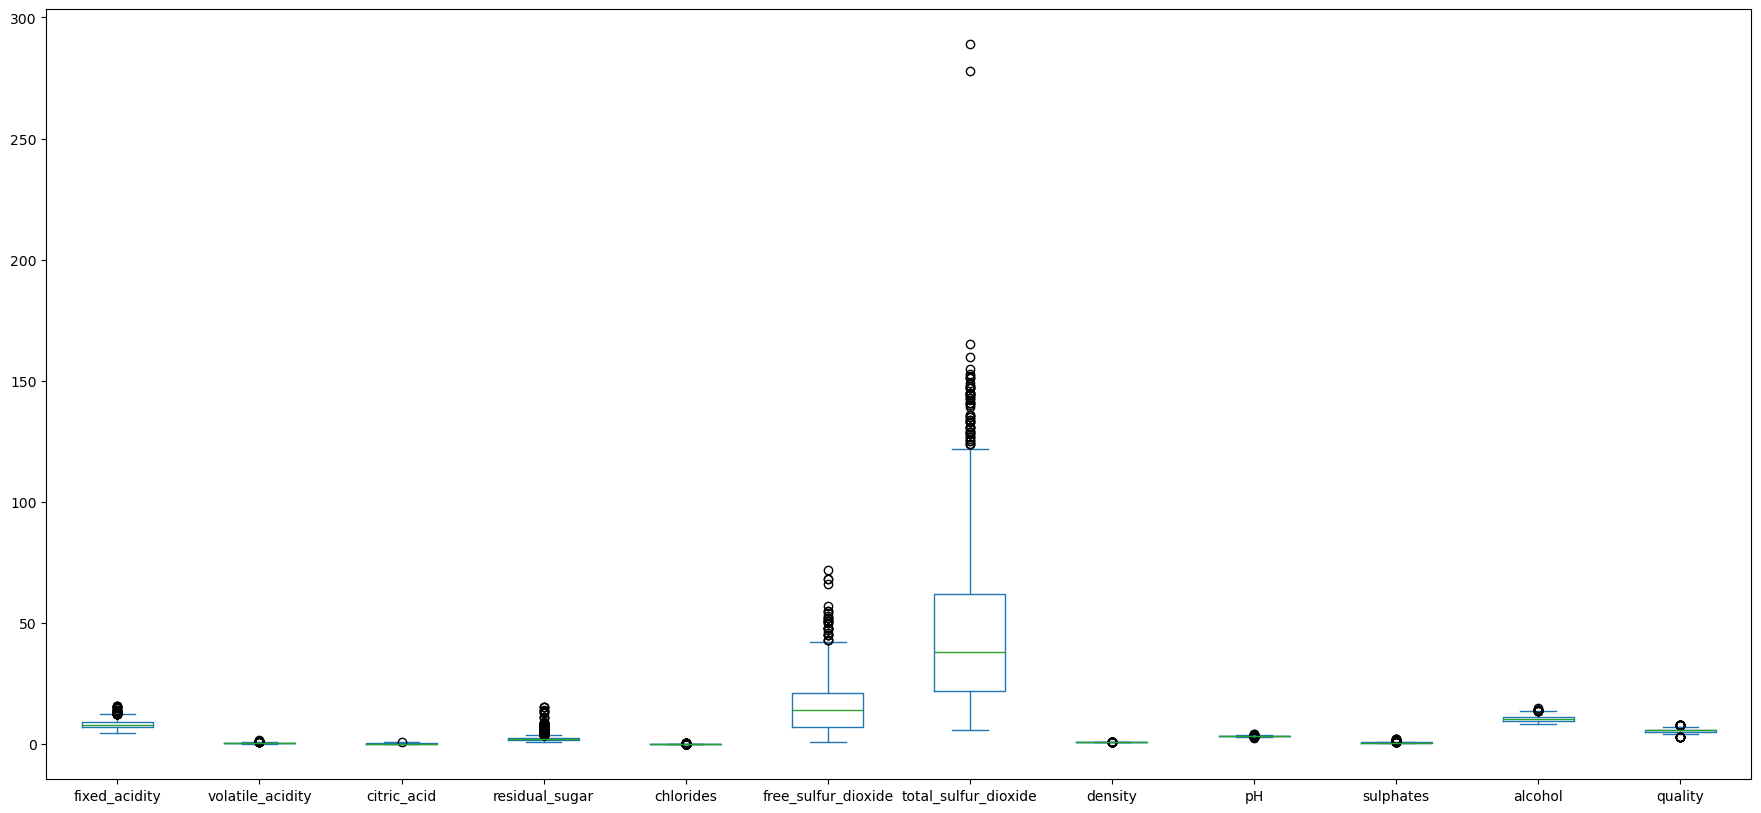

In [ ]:
cols_f = winequality_df.iloc[:, :12]
cols_f.plot(kind="box", subplots=True, layout=(3, 9), sharex=False, sharey=False, figsize=(20,10))
cols_f.plot(kind="box", figsize=(22,10))
plt.savefig("abc.pdf")

**Nhận xét:**
- Ngoại trử citric_acid ra các yếu tố khác đều có rất nhiều giá trị outlier, khiến chúng bị lệch phải và trái nhiều

2) Histogram


**Nhận xét:**
- Từ biểu đồ của fixed_acidity, volatile_acidity và citric_acid ta thấy rằng độ phân bố bị lệch phải 
- Tuy nhiên với biểu đồ fixed_acidity lại cân đối khi có 1 đỉnh, 2 biểu đồ còn lại thì xuất hiện nhiều đỉnh
1. Đối với fixed_acidity các giá trị nằm trong khoảng $[7-8]$
2. Đối với volatile_acidity các giá trị nằm trong khoảng $[0.4 - 0.7]$
3. Đối với citric_acid các giá trị nằm trong khoảng $[0.0 - 0.1]$

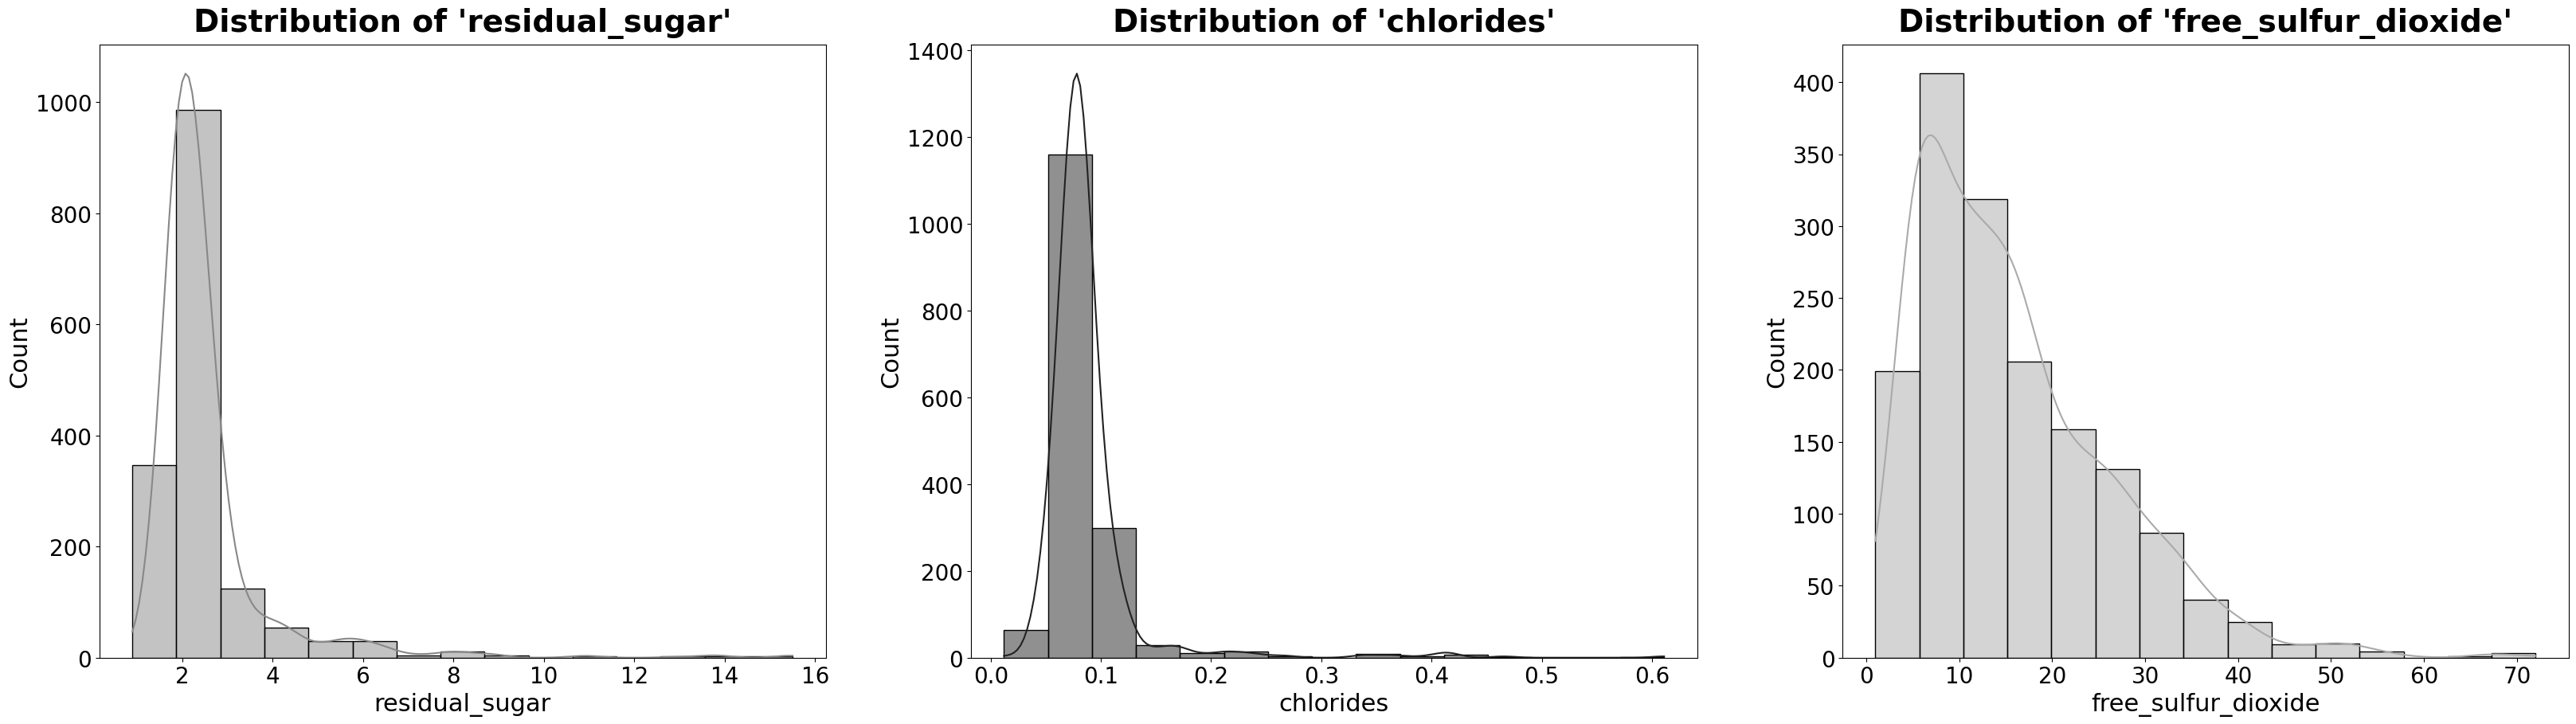

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (40, 10))
sns.histplot(ax = axes[0], x = winequality_df["residual_sugar"],
             bins = 15,
             kde = True,
             cbar = True,
             color = "#888888").set(title = "Distribution of 'residual_sugar'")

sns.histplot(ax = axes[1], x = winequality_df["chlorides"],
             bins = 15,
             cbar = True,
             kde = True,
             color = "#222222").set(title = "Distribution of 'chlorides'")

sns.histplot(ax = axes[2], x = winequality_df["free_sulfur_dioxide"],
             bins = 15,
             kde = True,   
             cbar = True,
             color = "#AAAAAA").set(title = "Distribution of 'free_sulfur_dioxide'")

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=22)
    ax.set_ylabel(ax.get_ylabel(), fontsize=22)
    ax.set_title(ax.get_title(), fontsize=28, fontweight="bold", pad=12)

**Nhận xét:**
- Từ biểu đồ của residual_sugar, chlorides và free_sulfur_dioxide ta thấy rằng độ phân bố bị lệch phải 
- Tuy nhiên cả 3 biểu đồ này đều khá cân đối
1. Đối với residual_sugar các giá trị nằm trong khoảng $[1 - 2.5]$
2. Đối với chlorides các giá trị nằm trong khoảng $[0.085 - 0.15]$
3. Đối với free_sulfur_dioxide các giá trị nằm trong khoảng $[0 - 15]$

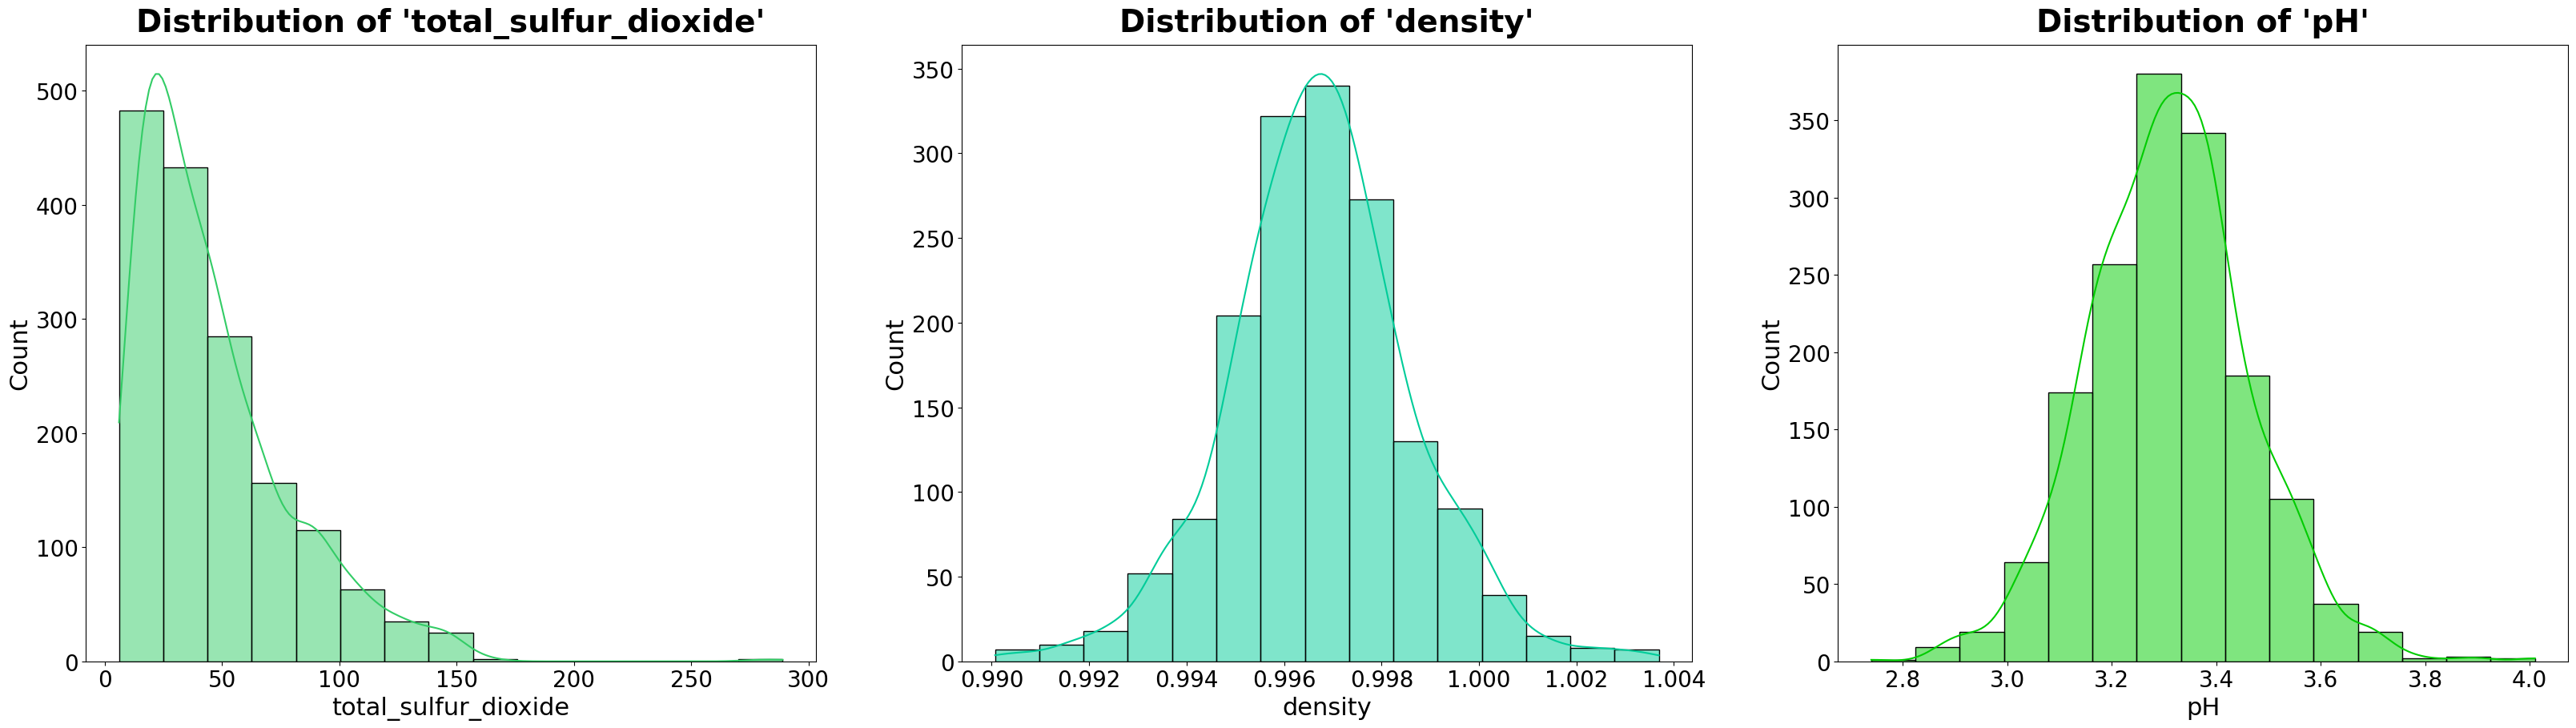

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (40, 10))
sns.histplot(ax = axes[0], x = winequality_df["total_sulfur_dioxide"],
             bins = 15,
             kde = True,
             cbar = True,
             color = "#33CC66").set(title = "Distribution of 'total_sulfur_dioxide'")

sns.histplot(ax = axes[1], x = winequality_df["density"],
             bins = 15,
             cbar = True,
             kde = True,
             color = "#00CC99").set(title = "Distribution of 'density'")

sns.histplot(ax = axes[2], x = winequality_df["pH"],
             bins = 15,
             kde = True,   
             cbar = True,
             color = "#00CC00").set(title = "Distribution of 'pH'")

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=22)
    ax.set_ylabel(ax.get_ylabel(), fontsize=22)
    ax.set_title(ax.get_title(), fontsize=28, fontweight="bold", pad=12)

**Nhận xét:**
- Từ biểu đồ của total_sulfur_dioxide, density và pH ta thấy rằng độ phân bố bị lệch phải 
- Tuy nhiên cả 3 biểu đồ này đều khá cân đối
1. Đối với total_sulfur_dioxide các giá trị nằm trong khoảng $[0 - 30]$
2. Đối với density các giá trị nằm trong khoảng $[0.995 - 0.998]$
3. Đối với pH các giá trị nằm trong khoảng $[3.2 - 3.4]$

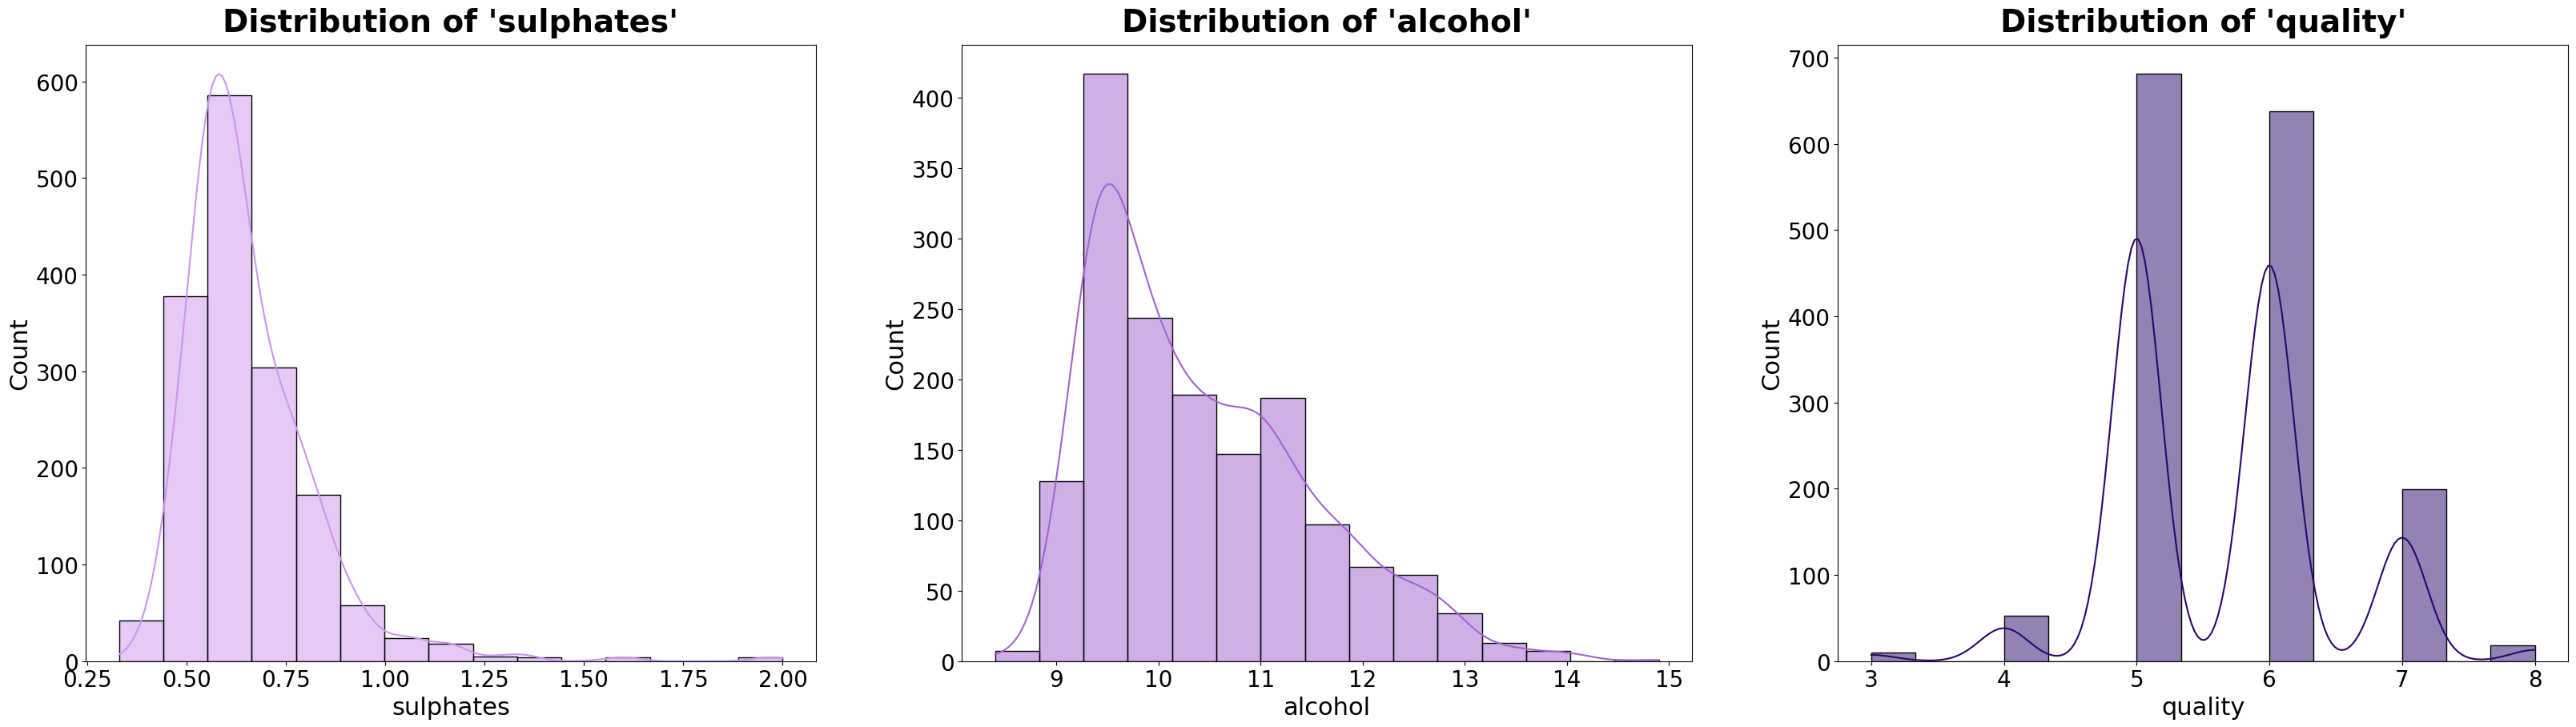

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (40, 10))
sns.histplot(ax = axes[0], x = winequality_df["sulphates"],
             bins = 15,
             kde = True,
             cbar = True,
             color = "#CA96EC").set(title = "Distribution of 'sulphates'")

sns.histplot(ax = axes[1], x = winequality_df["alcohol"],
             bins = 15,
             cbar = True,
             kde = True,
             color = "#A163CF").set(title = "Distribution of 'alcohol'")

sns.histplot(ax = axes[2], x = winequality_df["quality"],
             bins = 15,
             kde = True,   
             cbar = True,
             color = "#29066B").set(title = "Distribution of 'quality'")

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=22)
    ax.set_ylabel(ax.get_ylabel(), fontsize=22)
    ax.set_title(ax.get_title(), fontsize=28, fontweight="bold", pad=12)

**Nhận xét:**
- Từ biểu đồ của sulphates, alcohol ta thấy rằng độ phân bố bị lệch phải
- Tuy nhiên sulphates phân phối đều, đối với alcohol thì khá cân bằng. Ngoại trừ quality thì nhiều đỉnh khiến phân bố lộn xộn 
1. Đối với sulphates các giá trị nằm trong khoảng $[0.50 - 0.75]$
2. Đối với alcohol các giá trị nằm trong khoảng $[9 - 10]$
3. Đối với quality các giá trị nằm trong khoảng $5$ và $6$

3) Scatter

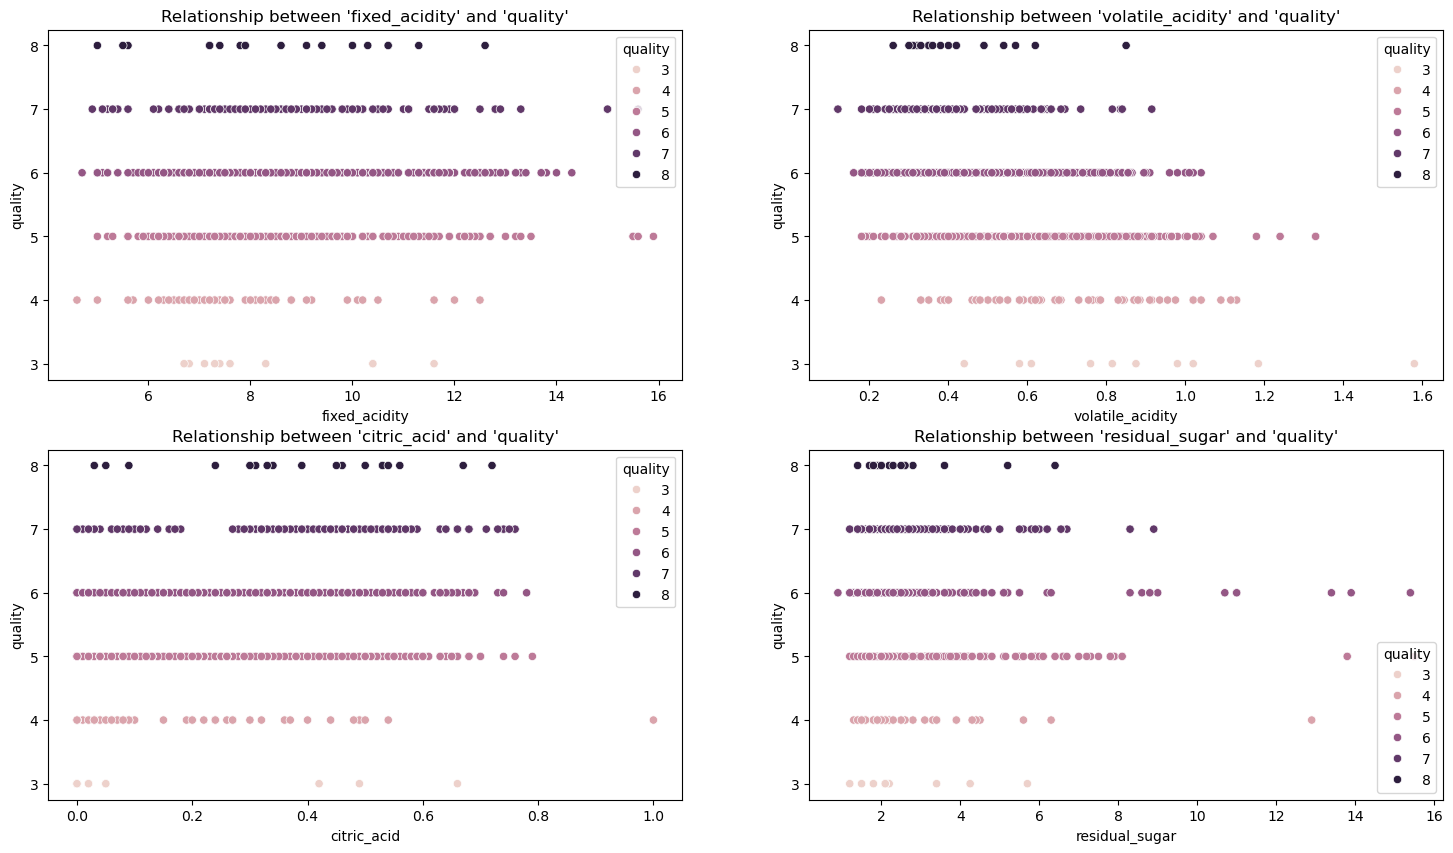

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

sns.scatterplot(ax = axes[0],
                x = "fixed_acidity",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'fixed_acidity' and 'quality'");

sns.scatterplot(ax = axes[1],
                x = "volatile_acidity",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'volatile_acidity' and 'quality'");

sns.scatterplot(ax = axes[2],
                x = "citric_acid",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'citric_acid' and 'quality'");

sns.scatterplot(ax = axes[3],
                x = "residual_sugar",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'residual_sugar' and 'quality'");

**Nhận xét**
- Fixed Acidity vs quality
    -	Đối với Fixed Acidity biểu đồ cho thấy sự phân tán rộng của các điểm dữ liệu. Các loại rượu có chất lượng từ thấp đến cao (cụ thể là từ 4 đến 7) xuất hiện trên toàn bộ dải giá trị của fixed_acidity, tuy nhiên với lượng Fixed Acidity [12-14 g/L] vẫn có tập trung chất lượng rượu khá (5,6). 

    => Axit cố định (Fixed Acidity) không phải là một yếu tố có ảnh hưởng rõ rệt hoặc một chỉ báo đáng tin cậy để dự đoán chất lượng rượu vang.
- Volatile Acidity vs quality
    -	Đối với Volatile Acidity biểu đồ thể hiện một mối tương quan nghịch (âm) rõ ràng. Các loại rượu có chất lượng cao (điểm 6, 7, 8) tập trung chủ yếu ở vùng có nồng độ volatile_acidity thấp (dưới 0.7), trong khi rượu chất lượng thấp hơn lại có xu hướng phân bố ở vùng nồng độ cao hơn.

    => Axit dễ bay hơi (Volatile Acidity) là một chỉ số quan trọng, ảnh hưởng tiêu cực đến chất lượng rượu. Về mặt hóa học, nồng độ cao của axit axetic (thành phần chính của volatile_acidity) sẽ tạo ra mùi giống giấm, một đặc tính không mong muốn, từ đó làm giảm chất lượng cảm quan của sản phẩm.
- Axit Citric vs quality
    -	Đối với Axit Citric mặc dù dữ liệu có độ phân tán, một xu hướng tương quan thuận (dương) có thể được nhận thấy. Cụ thể, khi nồng độ citric_acid vượt ngưỡng 0.5, mật độ các loại rượu có chất lượng cao tăng lên đáng kể.

    => Axit citric (Citric Acid) là một yếu tố có ảnh hưởng tích cực đến chất lượng rượu. Về mặt cảm quan, axit citric góp phần tạo nên sự tươi mát (freshness) và hương vị trái cây cho rượu, giúp nâng cao trải nghiệm của người dùng.
- Residual sugar vs quality
    -	Tương tự như fixed_acidity, biểu đồ của residual_sugar cho thấy các điểm dữ liệu phân tán rộng mà không tuân theo một quy luật hay xu hướng cụ thể nào.
    => Đường tồn dư (Residual Sugar) không cho thấy mối liên hệ rõ ràng với chất lượng rượu vang. Điều này cho thấy rằng vị ngọt không phải là yếu tố quyết định đến việc một loại rượu được đánh giá là ngon hay không trong tập dữ liệu này.



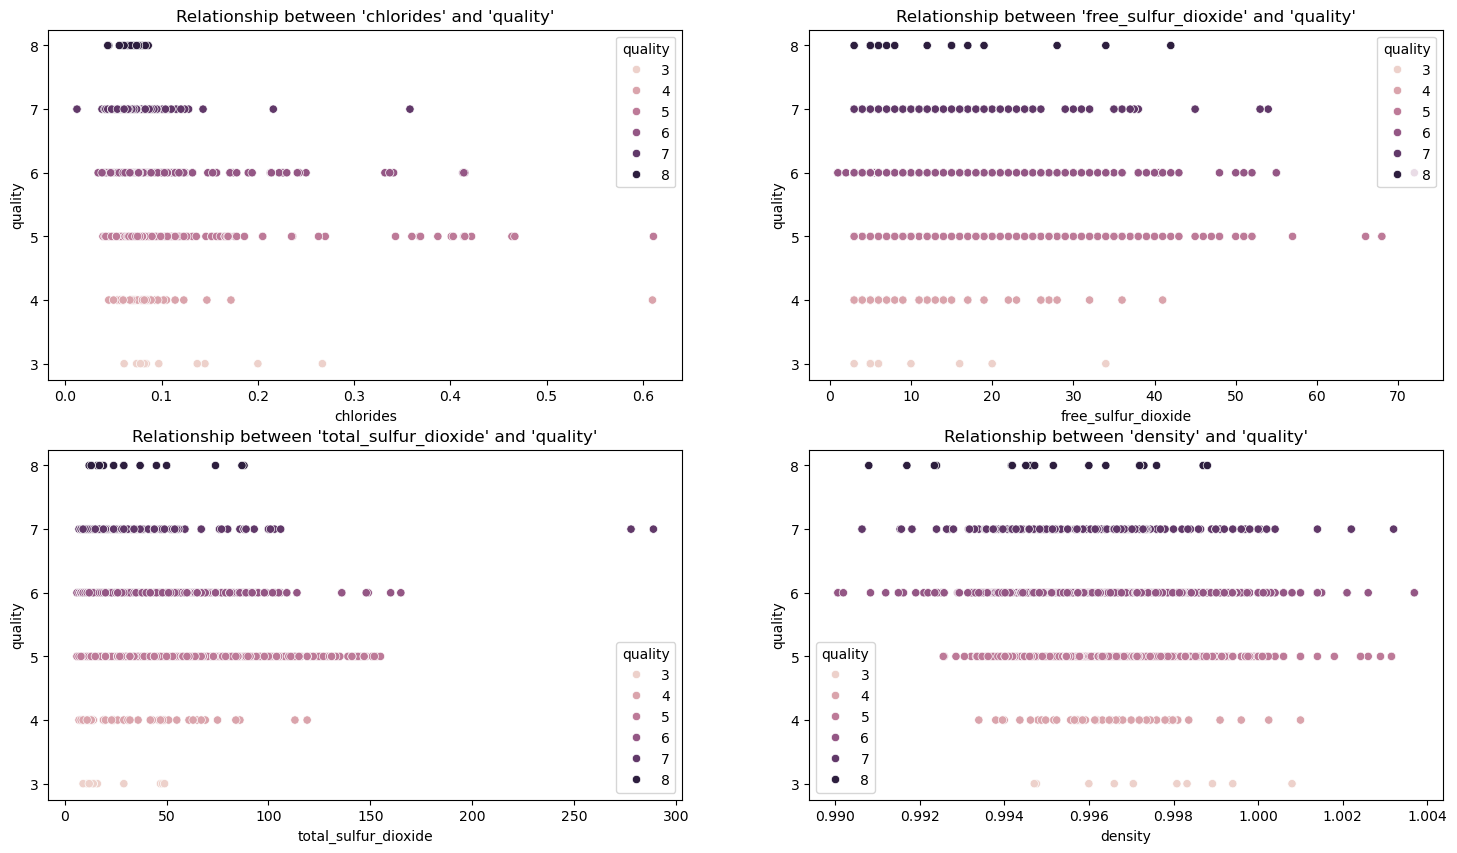

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

sns.scatterplot(ax = axes[0],
                x = "chlorides",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'chlorides' and 'quality'");

sns.scatterplot(ax = axes[1],
                x = "free_sulfur_dioxide",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'free_sulfur_dioxide' and 'quality'");

sns.scatterplot(ax = axes[2],
                x = "total_sulfur_dioxide",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'total_sulfur_dioxide' and 'quality'");

sns.scatterplot(ax = axes[3],
                x = "density",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'density' and 'quality'");

**Nhận xét:**
- Clorides vs quality
    -	Biểu đồ Clorides không cho thấy một mối tương quan. Các loại rượu có chất lượng từ thấp đến cao tuy tập trung vào nồng độ muối thấp (dưới 0.1 g/L) nhưng không cho thấy được là yếu tố gây ảnh hưởng đến chất lượng rượu.

    => Nồng độ muối là một yếu tố không ảnh hưởng đến chất lượng rượu.
- Free SO₂ vs quality
    -	Tương tự như fixed_acidity và residual_sugar, biểu đồ của free_SO₂ cho thấy các điểm dữ liệu phân tán rộng mà không hình thành một xu hướng rõ ràng. Ở mọi mức chất lượng, đều có sự hiện diện của rượu với hàm lượng SO₂ tự do từ thấp đến cao.
    
    => Dựa trên biểu đồ, lưu huỳnh đioxit tự do không phải là một yếu tố dự báo đáng tin cậy cho chất lượng rượu vang.
- Total SO₂ vs quality
    -	Mặc dù biểu đồ cũng cho thấy sự phân tán rộng, một khuynh hướng nhẹ có thể được nhận thấy. Tuy vậy nó vẫn không đánh giá được ảnh hưởng đến chất lượng rượu.
    
    => Tổng nồng độ SO₂ không phải là yếu tố ảnh hưởng đến chất lượng rượu. Tuy vào đó cần thắt chặt lượng SO₂ để đảm bảo an toàn sức khỏe người sử dụng 
- Density vs quality
    -	Biểu đồ thể hiện một mối tương quan nghịch rất rõ ràng và mạnh mẽ. Rượu chất lượng cao tập trung dày đặc ở vùng có tỷ trọng thấp (dưới 0.993 g/cm³), trong khi rượu chất lượng thấp hơn có xu hướng ở vùng tỷ trọng cao hơn.
    
    => Tỷ trọng là một yếu tố dự báo chất lượng quan trọng. Về mặt vật lý, tỷ trọng của rượu là một hàm số của hai thành phần chính: nồng độ cồn và đường tồn dư (đường làm tăng tỷ trọng). Như đã phân tích trước đó, rượu chất lượng cao thường có nồng độ cồn cao và lượng đường tồn dư không quá lớn. Sự kết hợp này dẫn đến tỷ trọng thấp hơn, biến density trở thành một chỉ báo tổng hợp hiệu quả cho chất lượng rượu.


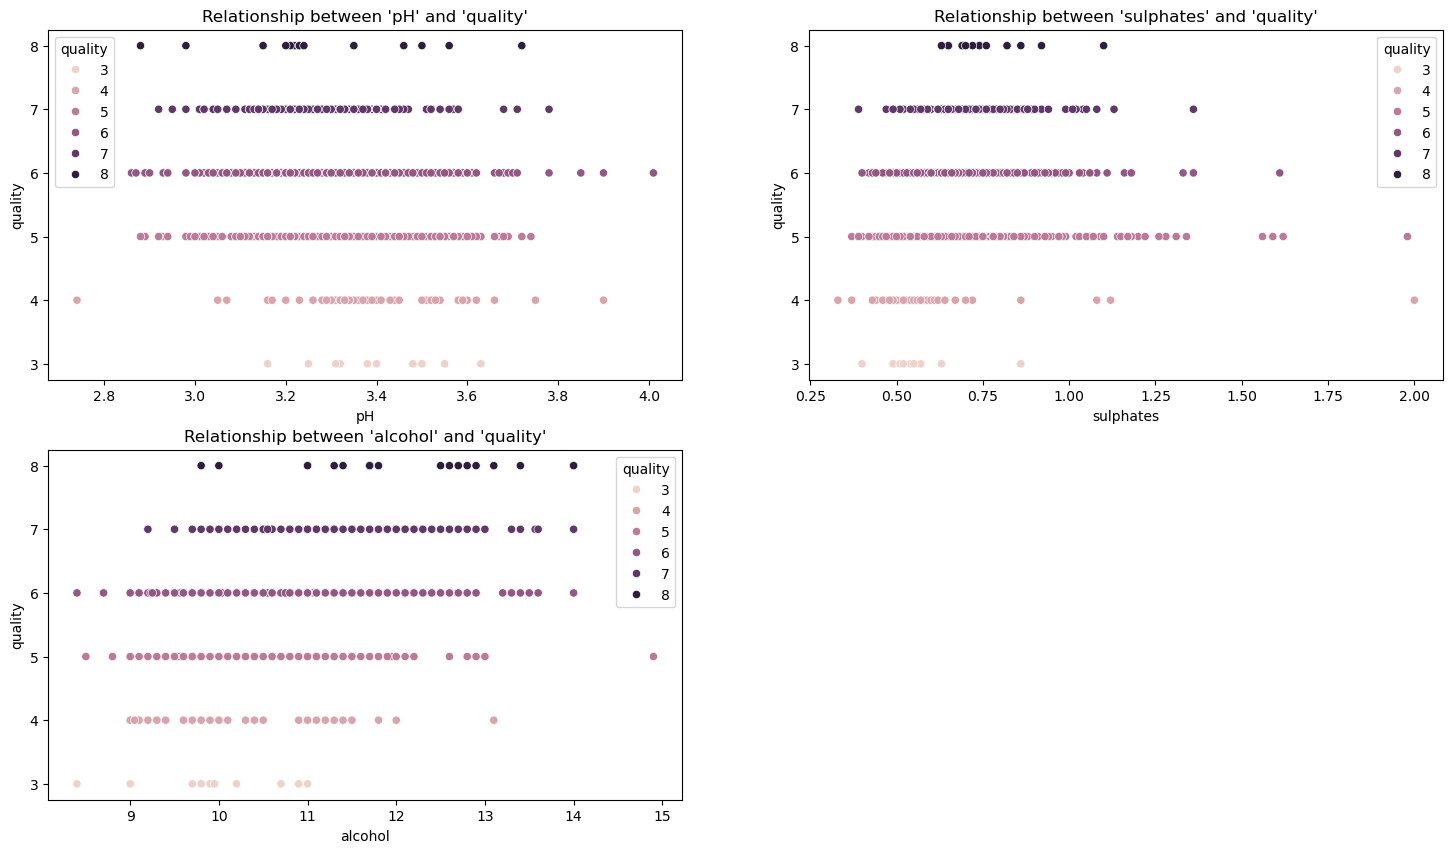

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

sns.scatterplot(ax = axes[0],
                x = "pH",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'pH' and 'quality'");

sns.scatterplot(ax = axes[1],
                x = "sulphates",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'sulphates' and 'quality'");

sns.scatterplot(ax = axes[2],
                x = "alcohol",
                y = "quality", hue = "quality",
                data = winequality_df).set(title = "Relationship between 'alcohol' and 'quality'");
fig.delaxes(axes[3])

**Nhận xét:**
- Density vs quality
    -	Mặc dù trên toàn dải giá trị, độ pH không cho thấy một xu hướng tuyến tính rõ ràng, việc phân tích sâu hơn vào các khoảng cụ thể lại phát hiện ra một insight quan trọng. Trong khoảng pH từ 2.9 đến dưới 3.2, có một sự tập trung đáng chú ý của các loại rượu chất lượng cao và không có sự hiện diện của rượu chất lượng thấp.

    => Độ pH trong khoảng hẹp [2.9, 3.2] có thể là một yếu tố ảnh hưởng tích cực đến chất lượng. Điều này cho thấy một độ axit cao và được kiểm soát chặt chẽ có thể là điều kiện cần để đạt được chất lượng tốt. Yếu tố này cần được nghiên cứu sâu hơn để xác nhận đây là một "khoảng giá trị tối ưu".
- Sulphates vs quality
    -	Biểu đồ cho thấy một vùng các điểm dữ liệu rõ rệt. Trong khoảng nồng độ từ 0.75 đến 1.20 g/L, có sự tập trung mạnh mẽ của các loại rượu có chất lượng tốt (điểm 6, 7). Ngoài khoảng này, dữ liệu trở nên phân tán hơn.
    
    => Hàm lượng sunfat là một yếu tố có ảnh hưởng mạnh, đặc biệt trong khoảng [0.75, 1.20]. Về mặt hóa học, sunfat (SO₄²⁻) là một nguồn cung cấp SO₂, một chất bảo quản và chống oxy hóa quan trọng. Việc duy trì nồng độ sunfat trong khoảng tối ưu này có thể giúp bảo vệ hương vị và cấu trúc của rượu một cách hiệu quả nhất.
- Alcohol vs quality
    -	Tương tự các yếu tố trên, việc xác định khoảng giá trị quan trọng mang lại nhiều thông tin hơn là nhìn vào xu hướng chung. Dữ liệu cho thấy trong khoảng nồng độ cồn từ 11% đến 14%, có sự hội tụ của các loại rượu chất lượng từ trung bình đến cao.
    
    => Nồng độ cồn là một yếu tố then chốt, với khoảng tối ưu nằm trong khoảng [11%, 14%]. Nồng độ cồn cao ảnh hưởng đến cảm nhận về hương vị và sự cân bằng tổng thể. Việc đạt được nồng độ cồn trong khoảng này dường như là một yếu tố quan trọng để sản xuất ra rượu vang chất lượng.


**Từ tất cả các nhận định trên, ta phân chia các yếu tố thành các loại:**

| Ảnh hưởng mạnh                | Ảnh hưởng nhẹ             | Không ảnh hưởng  |
|------------------------------|---------------------------|------------------|
| `Volatile_acidity` \< 0.7    | `Fixed_acidity` 12–14     |`Chlorides`      |
| `Citric_acid` \> 0.5         | `Total_SO2` 70–120        | `Residual_Sugar` |
| `Sulphates` 0.75–1.20        | `Density` \< 0.993        | `Free_SO2`       |
| `Alcohol` 11–14              | `pH` 2.8–3.0              |                  |


# KẾT THÚC